# Problem 2:

---
# Exploratory Data Analysis (EDA)

In [ ]:
from sklearn.datasets import fetch_california_housing
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
from sklearn.model_selection import train_test_split

In [ ]:
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Combine feature names and target names for column headers
all_column_names = housing.feature_names + housing.target_names

# Combine feature data (X) and target data (y)
# np.c_ stacks arrays column-wise
combined_data = np.c_[housing.data, housing.target]

# Create the DataFrame
CHD_df = pd.DataFrame(combined_data, columns=all_column_names)

# Display the first few rows of the DataFrame
CHD_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#Descriptive Statistics
We computed summary statistics using:
`describe` Function

In [ ]:
CHD_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Results & Interpretation
- **Different scales**  
  Some features are on very different scales (like population vs income).  
  We should be careful when comparing them.

- **Mean vs Median**  
  For most features, the mean and median are close.  
  This means the data is not heavily skewed.

- **Variability**  
  Standard deviation shows how spread out the data is.  
  Some features vary more than others.

- **Outliers**  
  Features like AveRooms and Population have very large ranges.  
  This suggests possible outliers to check.

# Outliers Analysis and Interprete results
Boxplots were generated for selected features (`AveRooms`, `AveBedrms`).

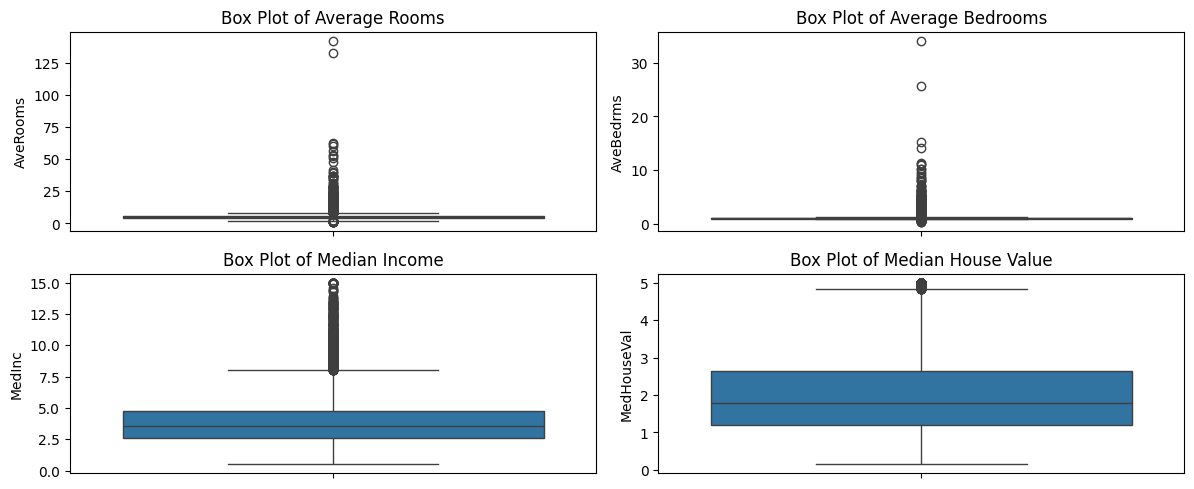

In [ ]:
#create  box plot for AveRooms  and AveBedrms
plt.figure(figsize=(12, 5))

plt.subplot(2, 2, 1)
sns.boxplot(y='AveRooms', data=CHD_df)
plt.title('Box Plot of Average Rooms')

plt.subplot(2, 2, 2)
sns.boxplot(y='AveBedrms', data=CHD_df)
plt.title('Box Plot of Average Bedrooms')

plt.subplot(2, 2, 3)
sns.boxplot(y='MedInc', data=CHD_df)
plt.title('Box Plot of Median Income')

plt.subplot(2, 2, 4)
sns.boxplot(y='MedHouseVal', data=CHD_df)
plt.title('Box Plot of Median House Value')

plt.tight_layout()
plt.show()

### Results & Interpretation

- **Visible outliers**  
  Outliers are present in both features.  
  Some values lie far beyond the interquartile range.

### Key Insight

- Outliers can affect parameter estimation in **Maximum Likelihood Estimation (MLE)**.  
- Gaussian models are sensitive to extreme values, so results may be distorted.

### Implication for MLE

- Outliers mean the **Gaussian noise assumption** may not fully hold.  
- Since outliers are few, MLE can still work reasonably well.


## Correlation Analysis (Heatmap)

In [ ]:
corr_mat = CHD_df.corr()

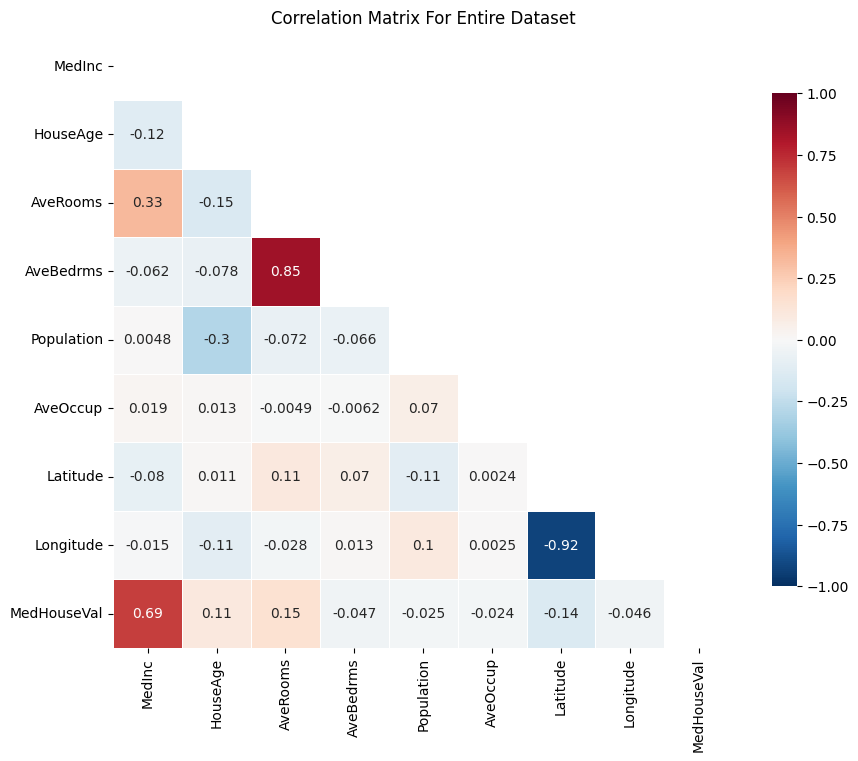

In [ ]:
plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1,
            annot=True, linewidths=.5, cbar_kws={'shrink':.8})
plt.title('Correlation Matrix For Entire Dataset')
plt.show()

### Results & Interpretation

- **Moderate correlation**  
  Some features show moderate correlation with the target (**MedHouseVal**).

- **Feature correlations**  
  There are also correlations between input features.  
  This means **multicollinearity** is present.


### Key Insight

- High correlation between features = **multicollinearity**.  
- It does not break Gaussian assumptions directly, but it matters for estimation.

### Implication for MLE
- Multicollinearity can make parameter estimates **unstable**.  
- It increases the **variance** of estimated coefficients.  
- Models may still work, but results should be interpreted with care.


# Distribution of Target Variable

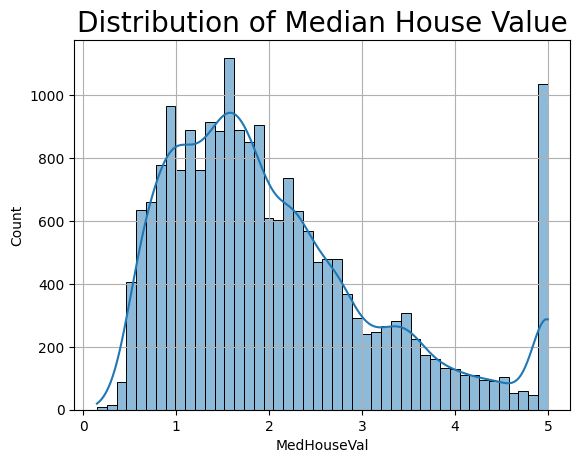

In [ ]:
sns.histplot(x='MedHouseVal', data = CHD_df,kde=True)
plt.style.use('fivethirtyeight')
plt.title('Distribution of Median House Value')
plt.grid(True)
plt.show()

### Results & Interpretation

- **Bell-shaped distribution**  
  The data looks roughly bell-shaped, but with slight skewness.

- **Clustering**  
  Most values are near the center, with fewer extreme values.

### Implication for MLE
- This supports the assumption of **Gaussian-distributed noise**.  
- A little skewness is acceptable in practice and usually does not cause problems.


# Feature vs Target (Scatter Plots)
Scatter plots were generated for each feature against the target.

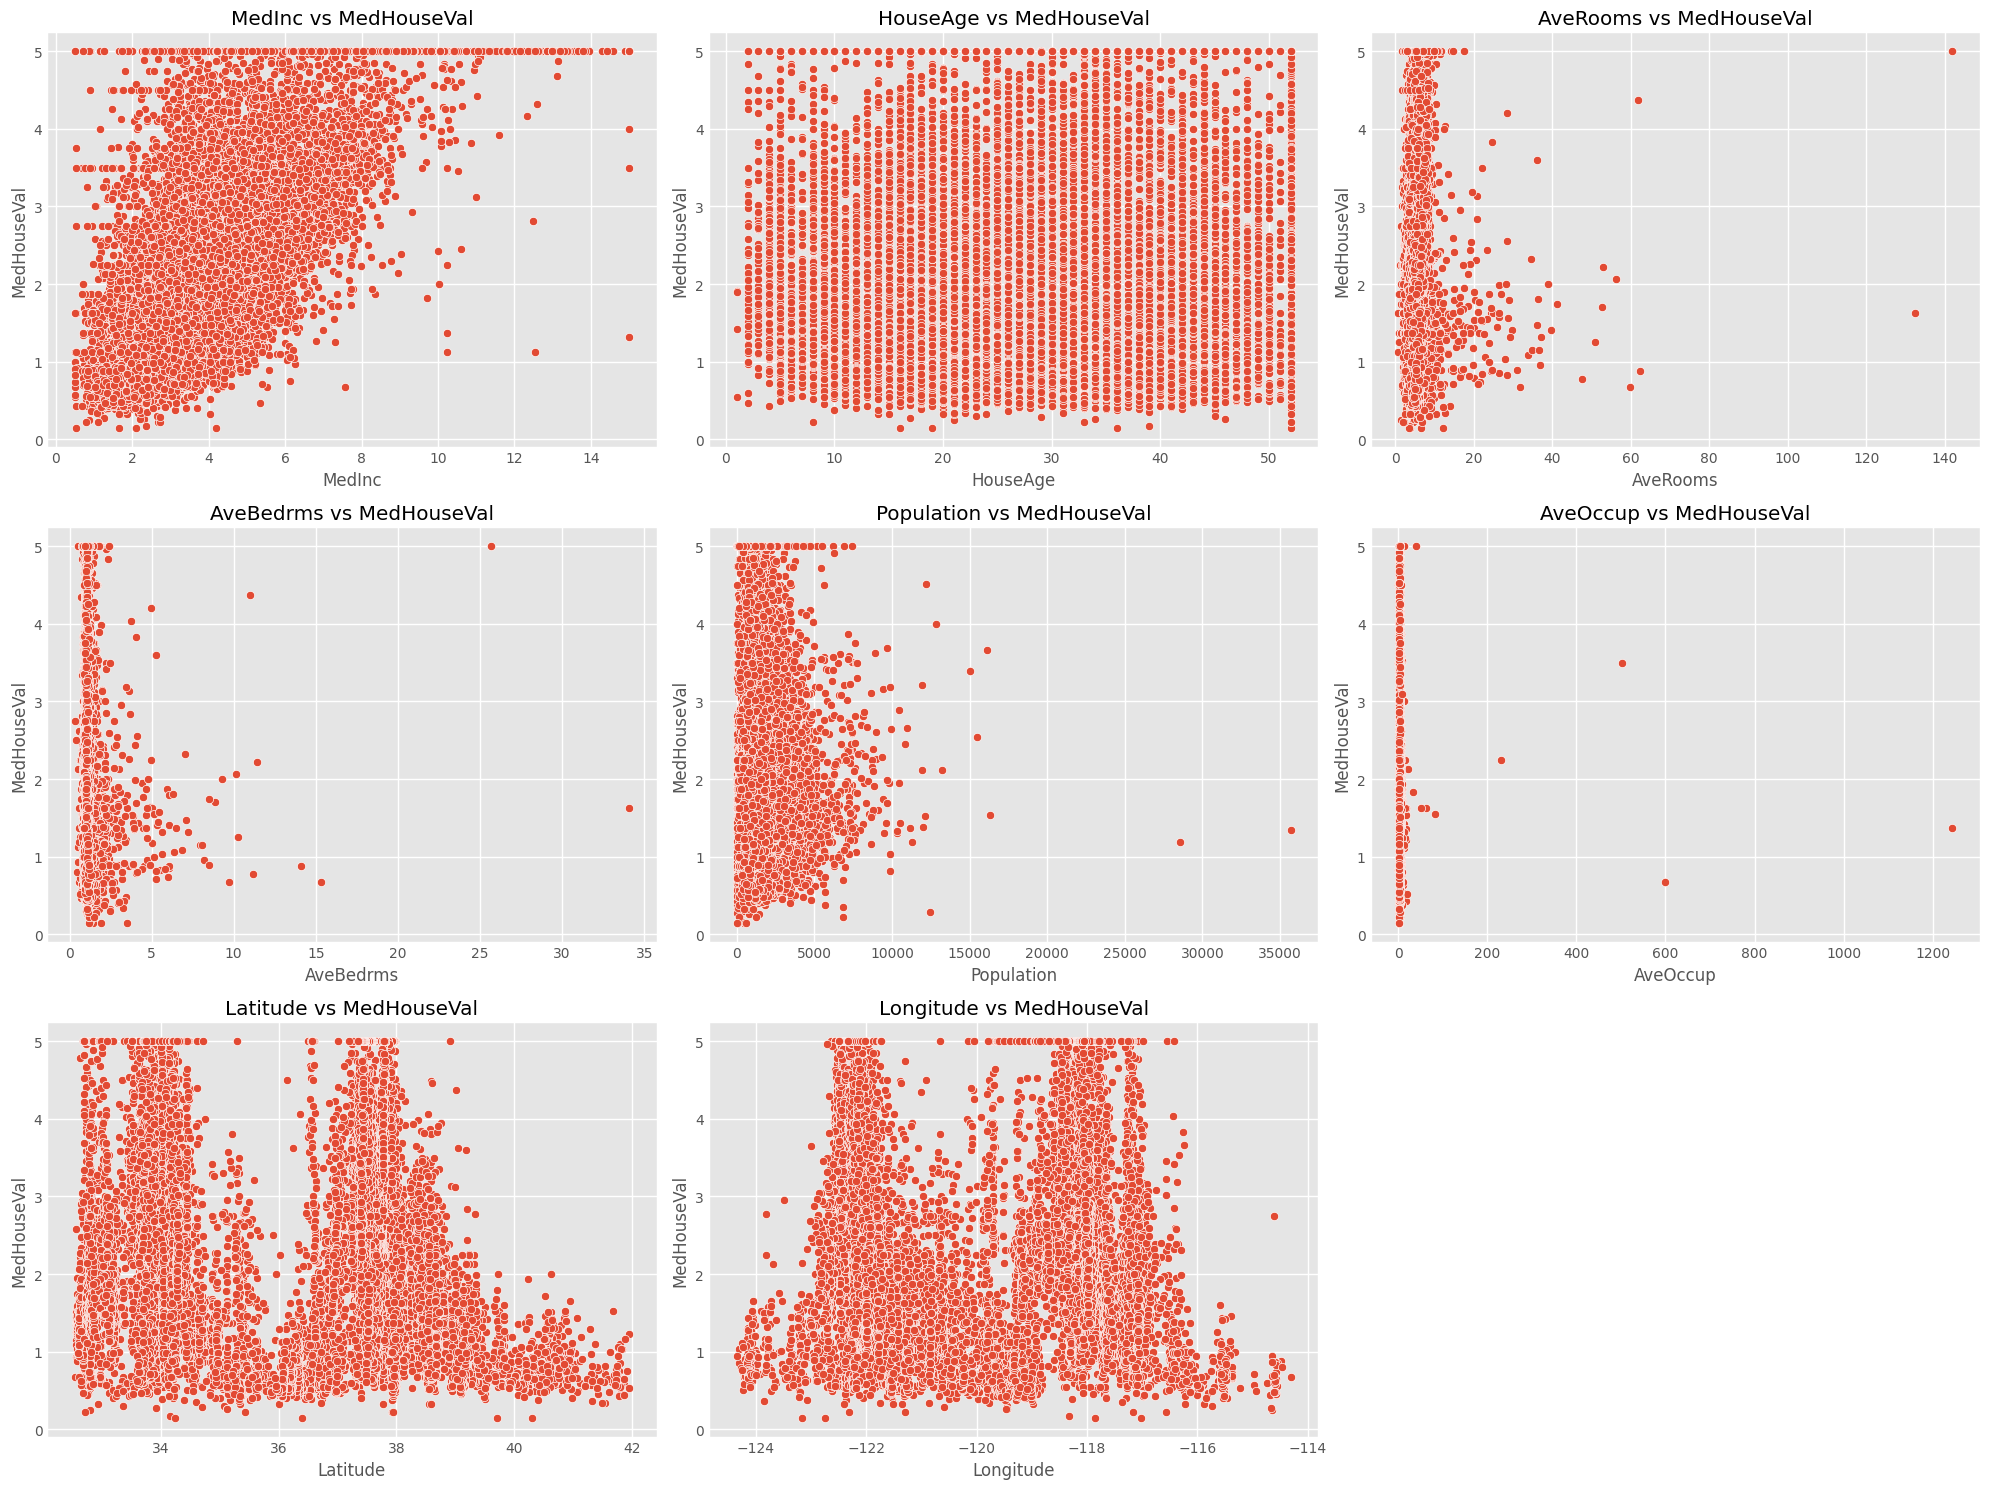

In [ ]:
feature_cols = [col for col in CHD_df.columns if col != 'MedHouseVal']

n_cols = 3
n_rows = (len(feature_cols) + n_cols - 1) // n_cols # Calculate number of rows needed

plt.style.use('ggplot')
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

y = CHD_df['MedHouseVal']

for i, col in enumerate(feature_cols):
    sns.scatterplot(x=CHD_df[col], y=y, ax=axes[i])
    axes[i].set_title(f'{col} vs MedHouseVal')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('MedHouseVal')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Results & Interpretation

- **Linear trend**  
  Some features (like income-related ones) show a clear linear trend with the target (**MedHouseVal**).

- **Weaker relationships**  
  Other features show weaker or more scattered patterns.

- **Data distribution**  
  Points are spread around an imaginary straight line, showing both trend and noise.

### Implication for MLE

- Supports the assumption of a **linear relationship** between features and the target.  
- The random spread around the line suggests **noise is present**, which is expected in practice.


#Problem 2

b) Normal Equation and Computational Complexity

The Normal Equation provides the closed‑form solution for the weights that minimize SSE (and thus maximize the log‑likelihood under Gaussian noise):

In [ ]:
# Add bias
X = CHD_df.drop('MedHouseVal', axis=1)
y = CHD_df['MedHouseVal']
X_np = np.c_[np.ones(X.shape[0]), X.values]

# Normal equation
w = np.linalg.inv(X_np.T @ X_np) @ X_np.T @ y.values
print('Weights')
w

Weights


array([-3.69419202e+01,  4.36693293e-01,  9.43577803e-03, -1.07322041e-01,
        6.45065694e-01, -3.97638942e-06, -3.78654265e-03, -4.21314378e-01,
       -4.34513755e-01])

## Complexity Breakdown
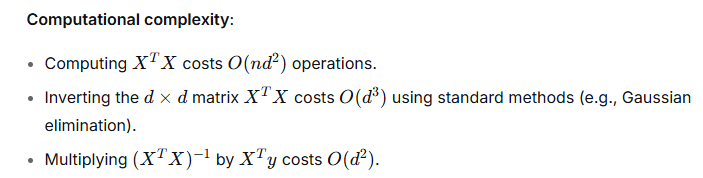

Thus the overall complexity is $O(nd^2 + d^3)$ For a large number of features d, the cubic term dominates, making the normal equation impractical.

#Problem 3


## (a) Negative Log‑Likelihood Function
From Problem 1, the log‑likelihood (ignoring constants that do not depend on w) is
\begin{equation}
\ell(w) = -\frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - w^T x_i)^2 + \text{const.}
\end{equation}

Thus the negative log‑likelihood (NLL) to be minimized is


\begin{equation}
J(w) = -\ell(w) = \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - w^T x_i)^2 + \text{const.}
\end{equation}


For optimization, the constant factor
$\frac{1}{\sigma^2}$ can be absorbed into the learning rate,

so we define
 \begin{equation}
\mathrm{gaussian\_nll}(w, X, y) = \frac{1}{2} \sum_{i=1}^{n} (y_i - w^T x_i)^2
\end{equation}

or equivalently, $\frac{1}{2} \| y - X w \|^2$

In [ ]:
## Gausian NLL Function definition.
def gaussian_nll(w, X, y):
    return 0.5 * np.sum((y - X @ w)**2)

## (b) Gradient of the Log‑Likelihood
We computed the gradient of ℓ(w) with respect to w.

$\ell(w) = - \frac{1}{2\sigma^2} (y - X w)^T (y - X w)$ using matrix calculus



\begin{equation}
[
\nabla_w \ell(w) = - \frac{1}{2\sigma^2} \cdot 2 X^T (X w - y) = \frac{1}{\sigma^2} X^T (y - X w)
]
\end{equation}



Therefore, the gradient of the NLL, $J(w) = -\ell(w)$ is \begin{equation}
\quad \nabla_w J(w) = - \nabla_w \ell(w) = - \frac{1}{\sigma^2} X^T (y - X w) = \frac{1}{\sigma^2} X^T (X w - y)
\end{equation}


## (c) Gradient Descent Implementation
Below is the Implementation of Gradient Descent to minimize the Negative Log-Likelihood and update w over 1000 iterations.

In [ ]:
def gradient_descent(X, y, lr=1e-11, iters=1000):
    w = np.zeros(X.shape[1])
    losses = []

    for _ in range(iters):
        grad = X.T @ (X @ w - y)
        w -= lr * grad
        losses.append(gaussian_nll(w, X, y))

    return w, losses

w_gd, losses = gradient_descent(X_np, y.values)

## d) Plot of the Negative Log-Likelihood value over each iteration

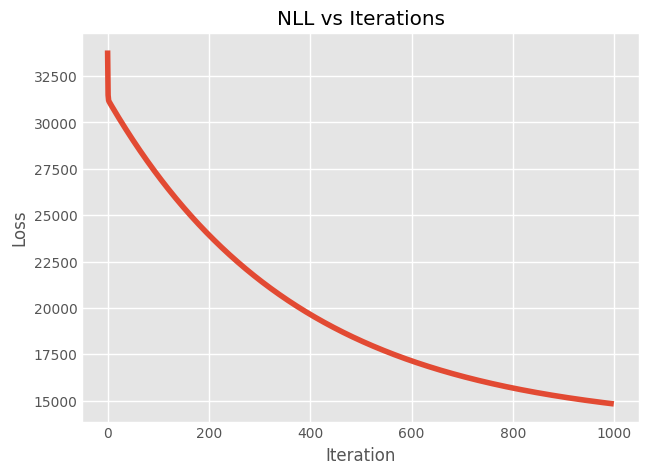

In [ ]:
plt.plot(losses)
plt.title("NLL vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

### Interpretation:
Curve is convex (parabolic shape)

Smooth monotonic decrease

Convergence rate: linear(Depending on Choosen Learning Rate).

### Why convexity is desired in MLE
Convexity guarantees any local minimum is global for MLE this ensures the optimizer finds the global maximizer of the likelihood (or minimizer of NLL).

This removes concerns about multiple local optima and makes optimization robust and predictable.

# Problem 04
## (a) MLE of Noise Variance


In [ ]:
y_pred = X_np @ w
sigma2 = np.mean((y.values - y_pred)**2)
print(sigma2)

0.524320986184607


### Interpretation:
 Since Value is small it indicates that the model explains most of the variability in 𝑦 (predictions are reliable) if the value was large it would indicate high uncertainty

## b)Comparison Between Normal Equation and Gradient Descent

In [ ]:
#To Be Implemented And Interpreted
print(sorted(w))
print(sorted(w_gd))


[np.float64(-36.94192020630866), np.float64(-0.43451375466457737), np.float64(-0.4213143775180024), np.float64(-0.10732204139378053), np.float64(-0.003786542654993447), np.float64(-3.9763894208274435e-06), np.float64(0.00943577803339045), np.float64(0.43669329313679733), np.float64(0.6450656935308542)]
[np.float64(-0.011065726335051452), np.float64(9.224546194271476e-05), np.float64(9.95122397226175e-05), np.float64(0.00014055261841787204), np.float64(0.00022348490371375382), np.float64(0.0006113028334458116), np.float64(0.0006681845624708233), np.float64(0.003232033853517301), np.float64(0.003307156757539469)]


##c) Model Evaluation


R2: 0.6122180481327448
MSE: 0.5194716929210514


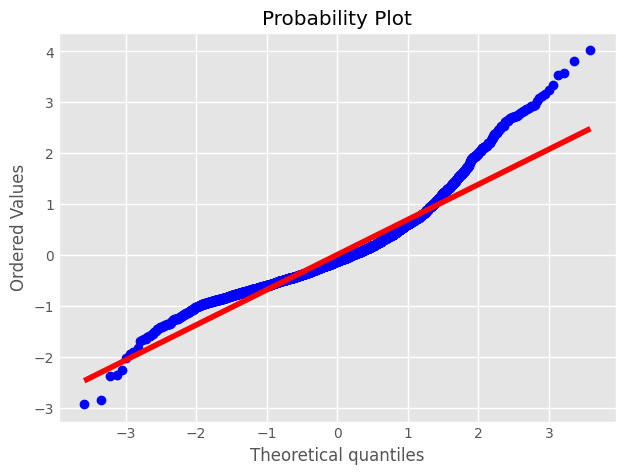

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_np, y, test_size=0.2)

# Predict
y_pred = X_test @ w

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# QQ plot
residuals = y_test - y_pred
stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

# Problem 05
## (a) Adam Optimizer
Adam (Adaptive Moment Estimation) combines momentum and adaptive learning rates.


In [ ]:
# (a) Running the optimization framework using the Adam optimizer.
def adam(X, y, lr=0.01, iters=1000, beta1=0.9, beta2=0.999, eps=1e-8):
    w = np.zeros(X.shape[1])
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    losses = []

    for t in range(1, iters+1):
        grad = X.T @ (X @ w - y)

        m = beta1*m + (1-beta1)*grad
        v = beta2*v + (1-beta2)*(grad**2)

        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        w -= lr * m_hat / (np.sqrt(v_hat) + eps)

        losses.append(gaussian_nll(w, X, y))

    return w, losses

### Visualizing Adam Optimizer vs Iterations

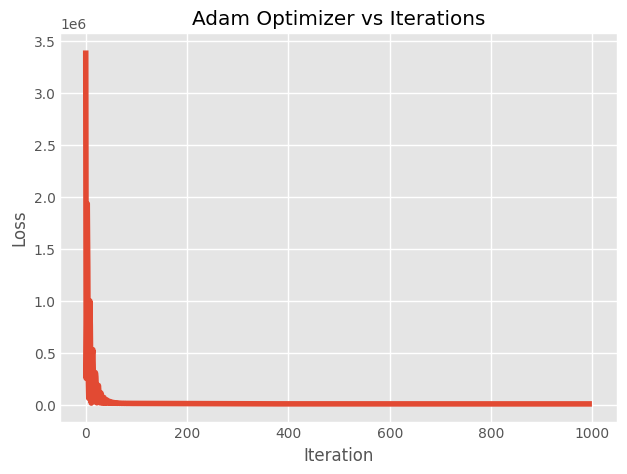

In [ ]:
w_adam, losses_adam =  adam(X_np, y.values)
plt.plot(losses_adam)
plt.title("Adam Optimizer vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

## b)Plotting the convergence curve (NLL vs. Iteration) for both Standard Gradient Descent

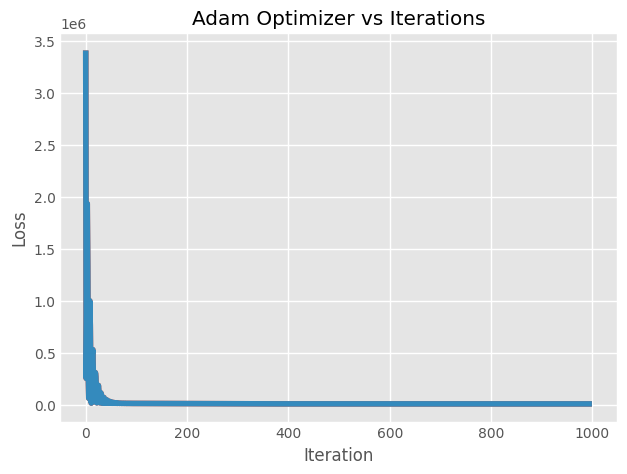

In [ ]:
## Plot the convergence curve (NLL vs. Iteration) for both Standard Gradient Descent
# (η = 0.01) and the Adam optimizer on the same set of axes
plt.plot(losses_adam)
plt.plot(losses)
plt.title("Adam Optimizer vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()


#### c)Analysis and Interpretation

##### Convergence
Adam typically converges in fewer iterations than SGD.  
This is because Adam adapts the learning rate for each parameter by combining:
- **Momentum**: leveraging past gradients to smooth updates  
- **Scaling**: adjusting step sizes based on gradient magnitudes  

##### Minimum
Since the optimization surface is convex, both Adam and SGD will eventually reach the same minimum.  
Adam’s advantage lies in efficiency—it navigates the loss landscape more smoothly and quickly.
